# Sweep `build_reduced_fov_path` parameter combinations

`positions.py`'s `build_reduced_fov_path` unifies the grid-building choice
(regular vs. irregular, optional grid-offset-phase optimization) with
mandatory redundant-FOV removal (`find_fully_redundant_fovs` -- always
applied, not a toggle) into one function call, mirroring
`segment_mosaic_tissue`'s single-function design for boundary derivation.

This notebook sweeps every combination of its two requested parameters --
`irregular_grid` and `optimize_offset` -- against a real mosaic-derived
boundary, to find which combination gives the lowest FOV count. The
irregular-grid combinations also sweep `fixed_axis` ("y"/"x") on top of
that: it's a real, non-trivial parameter of `build_irregular_boundary_path`/
`optimize_irregular_grid` not mentioned in the original request, so 4
combinations becomes 6 (2 regular + 2x2 irregular).

**Verify step (before implementing)**: is there another function, similar
to `optimize_grid_offset`, that has been investigated but not implemented
for reducing FOV count? Reviewed `FINDINGS.md` and every
`notebooks/tests/decrease_fov_number/*.ipynb` -- no. The only two
grid-phase-search functions that exist (`optimize_grid_offset` for the
regular grid, `optimize_irregular_grid` for the irregular one) are both
already implemented, and `find_fully_redundant_fovs` (the other lever) is
too. The only *other* lever this investigation surfaced (boundary
tightening -- tighter `segment_mosaic_tissue` morphology parameters) is not
a grid-building function and already shipped as `02_create_boundary_from_
mosaic.ipynb`'s production defaults -- out of scope here.


## 1 — Setup


In [1]:
import os
import sys
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.ops import unary_union

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as before_imaging/{regular,multi_z}/ -- see CLAUDE.md.
MERCI_DIR  = Path(os.getcwd()).parent.parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_fov_geometry
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons, build_reduced_fov_path,
)
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "02_sweep_reduced_fov_path_combinations"
DATA_DIR      = MERCI_DIR / "cache" / "tests" / "create_positions" / NOTEBOOK_NAME / "data" / "boundary"
FIGURES_DIR   = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="create_positions")

print(f"MERCI_DIR  : {MERCI_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")


MERCI_DIR  : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci
DATA_DIR   : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/tests/create_positions/02_sweep_reduced_fov_path_combinations/data/boundary
FIGURES_DIR: /n/home06/lsepulvedaduran/251225_LT027_saving_time/figures/MERci/tests/create_positions/02_sweep_reduced_fov_path_combinations


## 2 — Load the benchmark boundary (real LT066_sample_01/merfish mosaic-derived tissue)

Same real "lineage_merfish" acquisition used throughout
`notebooks/tests/decrease_fov_number/` -- a real, complex single-tissue
boundary + 11 holes, produced by that experiment's own
`02_create_boundary_from_mosaic.ipynb` run (production defaults). Copied
once into this notebook's own `DATA_DIR` (see `NOTEBOOK_GUIDELINES.md`'s
"Test notebooks: stay portable" section) so every later cell reads only
from there, never the live experiment tree.


In [2]:
# One-time copy from the real experiment tree -- skipped once DATA_DIR exists.
SOURCE_BOUNDARY_DIR = Path(
    "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/"
    "LT066_sample_01/merfish/positions/boundaries/from_mosaic"
)
if not DATA_DIR.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for f in sorted(SOURCE_BOUNDARY_DIR.glob("*.txt")):
        shutil.copy2(f, DATA_DIR / f.name)
    print(f"Copied {len(list(DATA_DIR.glob('*.txt')))} boundary/hole file(s) "
          f"from LT066_sample_01/merfish (production from_mosaic boundary).")
else:
    print(f"Using existing local copy: {DATA_DIR}")

boundary_polygon = load_boundary_polygon(DATA_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(DATA_DIR)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon

print(f"Boundary area: {boundary_polygon.area / 1e6:.2f} mm^2")
print(f"Tissue area (boundary minus holes): {effective_tissue.area / 1e6:.2f} mm^2")
print(f"Holes      : {len(hole_polygons)}")


Using existing local copy: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/tests/create_positions/02_sweep_reduced_fov_path_combinations/data/boundary
Boundary area: 34.82 mm^2
Tissue area (boundary minus holes): 30.60 mm^2
Holes      : 11


## 3 — FOV/grid geometry

Same real geometry used throughout `decrease_fov_number/` for this
experiment: ST2 microscope, 60X objective, and the step size measured
directly from two consecutive same-column real production FOVs (not
`0.9 * FOV_SIZE_UM`, which is close but not exact) -- see
`decrease_fov_number/01_investigate_fov_coverage_and_tissue_fraction_lt066.ipynb`'s
own section 3 cell.


In [3]:
pixel_size_um, image_size_px = get_fov_geometry("ST2", "60X")
FOV_SIZE_UM  = pixel_size_um * image_size_px
STEP_SIZE_UM = 182.06208

print(f"FOV size : {FOV_SIZE_UM:.2f} um")
print(f"Step size: {STEP_SIZE_UM:.2f} um")


FOV size : 202.29 um
Step size: 182.06 um


## 4 — Sweep every combination

`irregular_grid` x `optimize_offset` x (`fixed_axis` for the irregular
combinations) x `remove_redundant_fovs` -- 12 combinations total. The
first three give the same 6 base grid configurations as before;
`remove_redundant_fovs` is swept independently on top of each one (not
always on) so that offset optimization and redundant-FOV removal can be
compared on their own rather than one masking the other's effect (see
`build_reduced_fov_path`'s own docstring: with removal always on, the two
methods draw from the same pool of "wasted" tip/corner FOVs, so stacking
them isn't strictly additive and can look worse than either alone).


In [4]:
BASE_COMBOS = [
    dict(label="regular",                          irregular_grid=False, optimize_offset=False, fixed_axis=None),
    dict(label="regular + optimize_offset",         irregular_grid=False, optimize_offset=True,  fixed_axis=None),
    dict(label="irregular (fixed_axis=y)",          irregular_grid=True,  optimize_offset=False, fixed_axis="y"),
    dict(label="irregular (fixed_axis=y) + offset", irregular_grid=True,  optimize_offset=True,  fixed_axis="y"),
    dict(label="irregular (fixed_axis=x)",          irregular_grid=True,  optimize_offset=False, fixed_axis="x"),
    dict(label="irregular (fixed_axis=x) + offset", irregular_grid=True,  optimize_offset=True,  fixed_axis="x"),
]

results = {}
i = 0
n_total = len(BASE_COMBOS) * 2
for base in BASE_COMBOS:
    for remove_redundant in (True, False):
        i += 1
        label = f"{base['label']}\n({'redundant removed' if remove_redundant else 'no redundant removal'})"
        kwargs = dict(step_size=STEP_SIZE_UM, fov_size_um=FOV_SIZE_UM,
                      irregular_grid=base["irregular_grid"], optimize_offset=base["optimize_offset"],
                      remove_redundant_fovs=remove_redundant)
        if base["fixed_axis"] is not None:
            kwargs["fixed_axis"] = base["fixed_axis"]
        t0  = time.time()
        res = build_reduced_fov_path(boundary_polygon, hole_polygons, **kwargs)
        dt  = time.time() - t0
        results[label] = res
        print(f"[{i:2d}/{n_total}] {label.replace(chr(10), ' '):55s} "
              f"n_fovs: {res.n_fovs_before_redundant:4d} -> {len(res.coords):4d}   "
              f"uncovered: {res.redundant.uncovered_area_um2:9.2f} um^2   ({dt:.1f}s)")


[ 1/12] regular (redundant removed)                             n_fovs: 1138 -> 1096   uncovered:      1.33 um^2   (0.7s)


[ 2/12] regular (no redundant removal)                          n_fovs: 1138 -> 1138   uncovered:      1.33 um^2   (0.6s)


[ 3/12] regular + optimize_offset (redundant removed)           n_fovs: 1123 -> 1099   uncovered:      0.00 um^2   (20.4s)


[ 4/12] regular + optimize_offset (no redundant removal)        n_fovs: 1123 -> 1123   uncovered:      0.00 um^2   (20.5s)


[ 5/12] irregular (fixed_axis=y) (redundant removed)            n_fovs: 1130 -> 1099   uncovered:      0.00 um^2   (0.8s)


...

[ 8/12] irregular (fixed_axis=y) + offset (no redundant removal) n_fovs: 1128 -> 1128   uncovered:      0.00 um^2   (2.2s)


[ 9/12] irregular (fixed_axis=x) (redundant removed)            n_fovs: 1141 -> 1113   uncovered:      0.02 um^2   (0.6s)


[10/12] irregular (fixed_axis=x) (no redundant removal)         n_fovs: 1141 -> 1141   uncovered:      0.02 um^2   (0.6s)


[11/12] irregular (fixed_axis=x) + offset (redundant removed)   n_fovs: 1124 -> 1104   uncovered:      1.79 um^2   (1.9s)


[12/12] irregular (fixed_axis=x) + offset (no redundant removal) n_fovs: 1124 -> 1124   uncovered:      1.79 um^2   (1.9s)


## 5 — Summary table

`coverage_safe` flags combinations whose uncovered tissue area stays below
one thousandth of a FOV's own area (`FOV_SIZE_UM ** 2 / 1000`) --
generous enough to absorb floating-point-residual polygon slivers but far
below a real gap. `remove_redundant_fovs` records which combinations
actually had redundant-FOV removal applied (vs. just detected -- see
`build_reduced_fov_path`'s own docstring).


In [5]:
COVERAGE_EPS_UM2 = FOV_SIZE_UM ** 2 / 1000

rows = []
for label, res in results.items():
    uncovered = res.redundant.uncovered_area_um2
    rows.append(dict(
        combination=label,
        remove_redundant_fovs="(redundant removed)" in label,
        n_fovs_before_redundant=res.n_fovs_before_redundant,
        n_fovs_final=len(res.coords),
        n_redundant_removable=len(res.redundant.removed),
        uncovered_area_um2=uncovered,
        coverage_safe=uncovered < COVERAGE_EPS_UM2,
    ))
summary_df = pd.DataFrame(rows)
summary_df


,combination,remove_redundant_fovs,n_fovs_before_redundant,n_fovs_final,n_redundant_removable,uncovered_area_um2,coverage_safe
0,regular\n(redundant removed),True,1138,1096,42,1.333998,True
1,regular\n(no redundant removal),False,1138,1138,42,1.333998,True
2,regular + optimize_offset\n(redundant removed),True,1123,1099,24,0.000000,True
3,regular + optimize_offset\n(no redundant removal),False,1123,1123,24,0.000000,True
4,irregular (fixed_axis=y)\n(redundant removed),True,1130,1099,31,0.000000,True
5,irregular (fixed_axis=y)\n(no redundant removal),False,1130,1130,31,0.000000,True
6,irregular (fixed_axis=y) + offset\n(redundant ...,True,1128,1105,23,0.000000,True
7,irregular (fixed_axis=y) + offset\n(no redunda...,False,1128,1128,23,0.000000,True
8,irregular (fixed_axis=x)\n(redundant removed),True,1141,1113,28,0.017452,True
9,irregular (fixed_axis=x)\n(no redundant removal),False,1141,1141,28,0.017452,True


In [6]:
safe_df = summary_df[summary_df["coverage_safe"]]
if len(safe_df) == 0:
    print("WARNING: no combination is coverage-safe -- every one loses real tissue coverage.")
else:
    winner = safe_df.loc[safe_df["n_fovs_final"].idxmin()]
    print(f"Lowest FOV count among coverage-safe combinations: "
          f"'{winner['combination']}' -> {winner['n_fovs_final']} FOVs "
          f"(uncovered {winner['uncovered_area_um2']:.4f} um^2)")

unsafe_df = summary_df[~summary_df["coverage_safe"]]
if len(unsafe_df) > 0:
    print(f"\n{len(unsafe_df)}/{len(summary_df)} combination(s) are NOT coverage-safe "
          f"(real tissue left uncovered) -- excluded from the FOV-count comparison above:")
    for _, r in unsafe_df.iterrows():
        print(f"  {r['combination']:32s} uncovered {r['uncovered_area_um2']:9.2f} um^2 "
              f"({r['n_fovs_final']} FOVs)")


Lowest FOV count among coverage-safe combinations: 'regular
(redundant removed)' -> 1096 FOVs (uncovered 1.3340 um^2)


## 6 — Overlay plot: boundary + FOVs, every combination


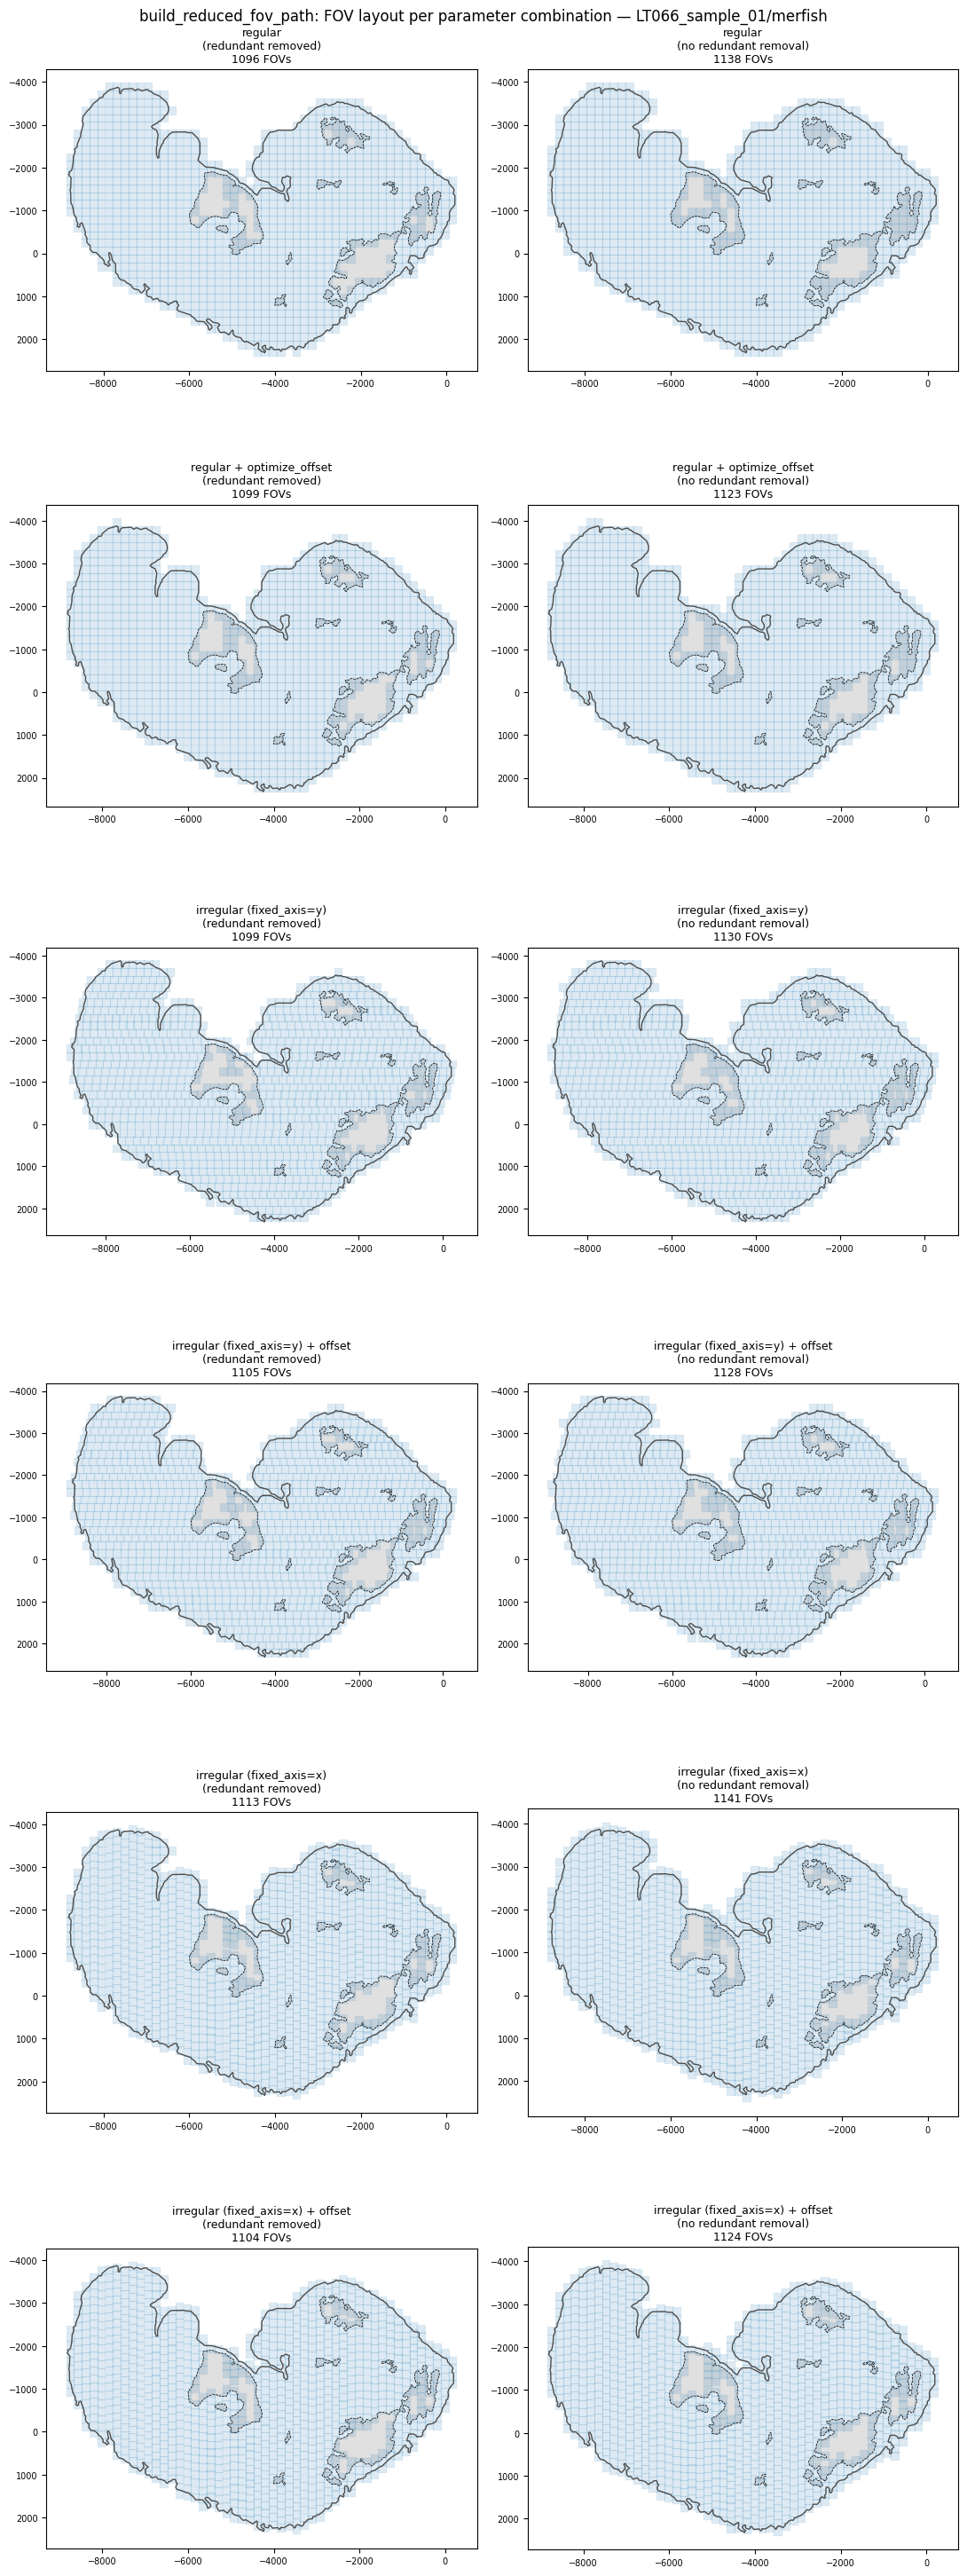

In [7]:
half = FOV_SIZE_UM / 2
n_combos = len(results)
n_cols = 2
n_rows = int(np.ceil(n_combos / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 5 * n_rows))
for ax, (label, res) in zip(axes.flat, results.items()):
    ax.plot(*boundary_polygon.exterior.xy, "-", lw=1.0, color="0.3")
    for hole in hole_polygons:
        ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
        ax.plot(*hole.exterior.xy, "k--", lw=0.5)
    for x, y in res.coords:
        ax.add_patch(mpatches.Rectangle(
            (x - half, y - half), FOV_SIZE_UM, FOV_SIZE_UM,
            lw=0.2, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.15,
        ))
    uncovered = res.redundant.uncovered_area_um2
    flag = "" if uncovered < COVERAGE_EPS_UM2 else f"  [{uncovered:.0f} um^2 uncovered]"
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"{label}\n{len(res.coords)} FOVs{flag}", fontsize=9)
    ax.tick_params(labelsize=7)

# Unused panels (n_combos not a multiple of n_cols) -- hide rather than leave a blank axes box.
for ax in axes.flat[n_combos:]:
    ax.set_visible(False)

fig.suptitle("build_reduced_fov_path: FOV layout per parameter combination — LT066_sample_01/merfish", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_layout_overlay.png", dpi=150)
plt.show()


## 7 — Bar graph: FOV count per combination


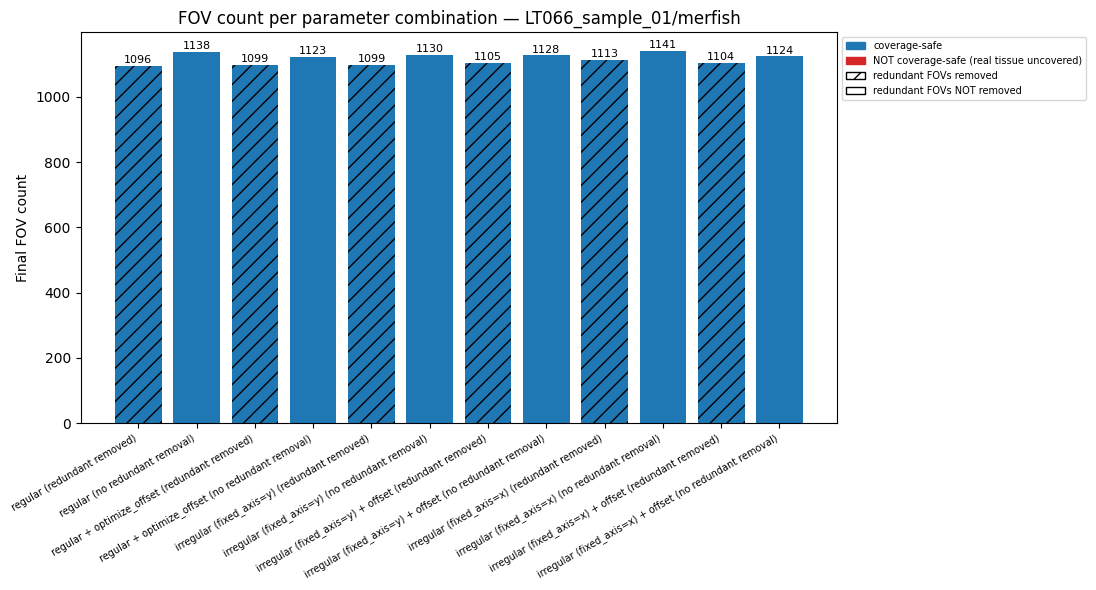

In [8]:
labels = list(results.keys())
n_fovs = [len(results[l].coords) for l in labels]
safe = [summary_df.set_index("combination").loc[l, "coverage_safe"] for l in labels]
removed = [summary_df.set_index("combination").loc[l, "remove_redundant_fovs"] for l in labels]
colors = ["tab:blue" if s else "tab:red" for s in safe]
hatches = ["//" if r else None for r in removed]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(range(len(labels)), n_fovs, color=colors)
for bar, n, h in zip(bars, n_fovs, hatches):
    if h:
        bar.set_hatch(h)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(n),
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.replace(chr(10), " ") for l in labels], rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Final FOV count")
ax.set_title("FOV count per parameter combination — LT066_sample_01/merfish")
ax.legend(handles=[
    mpatches.Patch(color="tab:blue", label="coverage-safe"),
    mpatches.Patch(color="tab:red",  label="NOT coverage-safe (real tissue uncovered)"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="//", label="redundant FOVs removed"),
    mpatches.Patch(facecolor="white", edgecolor="black", label="redundant FOVs NOT removed"),
], fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_count_bar.png", dpi=150)
plt.show()


## 8 — Takeaways

- **Verify step (before implementing), answered**: no other grid-phase-
  search function similar to `optimize_grid_offset`, investigated but not
  implemented, was found. `optimize_grid_offset` (regular grid) and
  `optimize_irregular_grid` (irregular grid) were both already implemented
  in `positions.py`; `find_fully_redundant_fovs` too. `build_reduced_fov_path`
  unifies all three behind one call, per the request.

- **All 12 combinations are coverage-safe** (bar chart above is all blue).
  This includes `regular + optimize_offset`, which a previous run of this
  notebook found NOT coverage-safe at 40X (see
  `create_positions/04_sweep_reduced_fov_path_combinations_40x.ipynb`'s own
  Takeaways) -- root-caused and fixed in `create_grid_positions` itself
  (`create_positions/05_guarantee_offset_grid_coverage.ipynb` has the full
  diagnosis); this notebook re-confirms the fix holds at 60X too (it
  always did here, but is worth re-stating now that the fix exists).

- **With redundant-FOV removal now optional, `optimize_offset` and
  redundant-FOV removal can finally be compared independently** (this was
  the whole point of adding the toggle -- with removal always mandatory,
  as in the first version of this notebook, `optimize_offset`'s own effect
  was invisible, masked by removal drawing from the same pool of "wasted"
  FOVs). On the plain regular grid, starting from the raw 1138-FOV grid:
    - `optimize_offset` ALONE (no redundant removal): 1138 -> 1123 (-15,
      ~1.3%)
    - redundant-FOV removal ALONE (no offset optimization): 1138 -> 1096
      (-42, ~3.7%) -- the bigger lever of the two, on its own
    - BOTH combined: 1138 -> 1099 (-39) -- smaller than redundant-removal
      alone (-42), confirming (now with both methods toggled truly
      independently, not inferred) that they draw from the same limited
      pool of "wasted" tip/corner FOVs rather than adding -- reproduces
      `decrease_fov_number/05_combine_offset_and_redundant_removal.ipynb`'s
      original finding.

- **Winner on this real boundary (LT066_sample_01/merfish, 30.60 mm^2
  tissue after subtracting 11 holes)**: `regular` with redundant-FOV
  removal, no offset optimization -> **1096 FOVs** -- still the lowest
  coverage-safe count, same conclusion as before, now on firmer footing
  since every combination is confirmed coverage-safe and the two
  contributing methods were checked independently rather than only in
  combination.

- **`fixed_axis` remains a real, non-trivial parameter**: `irregular
  (fixed_axis=y)` (1099) clearly beats `irregular (fixed_axis=x)` (1113)
  with redundant removal on -- not a cosmetic choice.

- **Function name**: `build_reduced_fov_path`, added to `positions.py` --
  not wired into `02_create_positions_from_boundaries.ipynb` in this
  request (validated here first, per this project's own convention).
